# NB07 — Marine and Geological Proxies

**Type:** EXPLORATORY — post-hoc, not confirmatory  
**Status:** PENDING EXECUTION  

Exploratory assessment of geological metal availability proxies (rock geochemistry, soil types,
marine sediment). No confirmatory tests.

## Pre-specifications

- All findings labelled EXPLORATORY
- No FDR correction or significance claims
- Report effect sizes and coverage as descriptive only

## Expected outputs

- INTERPRETATION_TABLE.md §7 updated
- data/07_geological_proxies.csv (if available)


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, run_multi_pgls, pgls_results_table, fdr_correct
from scripts.niche_utils import levins_b_std, genus_niche_summary
from scripts.spatial_utils import haversine_join
from scripts.berdl_utils import get_spark_session, load_local_pgls_input

pd.set_option('display.max_rows', 60)
print('Imports OK')

Imports OK


## Analysis Blocks (ALL EXPLORATORY — not confirmatory)

- **Block 1**: Setup + load local datasets (mgnify_genus_geo_niche.csv has pre-computed NGSA metal exposure per genus; NGSA raw geochemistry)
- **Block 2**: Spearman correlations between genus-level metal exposure and KO density / niche breadth; scatter plots
- **Block 3**: CMMI ores coverage check (Spark) + save + summary

**Pre-registration note:** All findings here are post-hoc. None can support/refute H1. Document notable correlations in INTERPRETATION_TABLE.md §7 for future confirmatory planning.


In [2]:
DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)

print('[NB07 — EXPLORATORY ONLY. No result here confirms or refutes H1.]\n')

gene_df = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')

bac_base = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')
bac_tax  = bac_base[['genus_lower', 'mean_levins_B_std', 'ko_per_mb_primary',
                      'predictor_z', 'phylum', 'kingdom']].copy()

# Pre-computed per-genus NGSA metal exposure from microbeatlas_metal_ecology project
geo_niche = pd.read_csv(DATA / 'mgnify_genus_geo_niche.csv')
geo_niche.columns = [c.lower() for c in geo_niche.columns]
if 'genus_lower' not in geo_niche.columns and 'genus' in geo_niche.columns:
    geo_niche['genus_lower'] = geo_niche['genus'].str.lower().str.strip()
elif 'genus_lower' in geo_niche.columns:
    geo_niche['genus_lower'] = geo_niche['genus_lower'].str.lower().str.strip()
print(f'geo_niche: {len(geo_niche)} genera')
print(f'Columns: {geo_niche.columns.tolist()[:12]}')

ngsa_df = pd.read_csv(DATA / 'ngsa_geochemistry.csv')
ngsa_df['lat'] = pd.to_numeric(ngsa_df['lat'], errors='coerce')
ngsa_df['lon'] = pd.to_numeric(ngsa_df['lon'], errors='coerce')
ngsa_df = ngsa_df.dropna(subset=['lat', 'lon'])
metal_ppm_cols = [c for c in ngsa_df.columns if '_ppm' in c.lower()]
print(f'NGSA: {len(ngsa_df)} sites, metals: {metal_ppm_cols[:5]}...')

_SPARK_AVAILABLE = False
_spark = None
try:
    _spark = get_spark_session()
    _SPARK_AVAILABLE = True
    print('Spark available for CMMI ores analysis')
except BaseException as _e:
    print(f'Spark unavailable. CMMI ores section skipped.')


[NB07 — EXPLORATORY ONLY. No result here confirms or refutes H1.]

geo_niche: 1424 genera
Columns: ['genus_lower', 'cu_mean', 'cu_sd', 'cu_n', 'zn_mean', 'zn_sd', 'zn_n', 'pb_mean', 'pb_sd', 'pb_n', 'ni_mean', 'ni_sd']
NGSA: 1315 sites, metals: ['Cu_ppm', 'Zn_ppm', 'Pb_ppm', 'Cd_ppm', 'Ni_ppm']...


[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
Spark available for CMMI ores analysis


Metal exposure columns in geo_niche: ['cu_mean', 'zn_mean', 'pb_mean', 'ni_mean', 'co_mean']
Genera with KO + metal exposure data: 180

Spearman correlations [EXPLORATORY — unadjusted]:
metal  n  r_vs_ko_density  p_vs_ko  r_vs_niche_breadth  p_vs_niche
   CU 18            0.339   0.1692               0.263      0.2911
   ZN 18            0.341   0.1665               0.197      0.4328
   PB 19            0.011   0.9630               0.003      0.9915


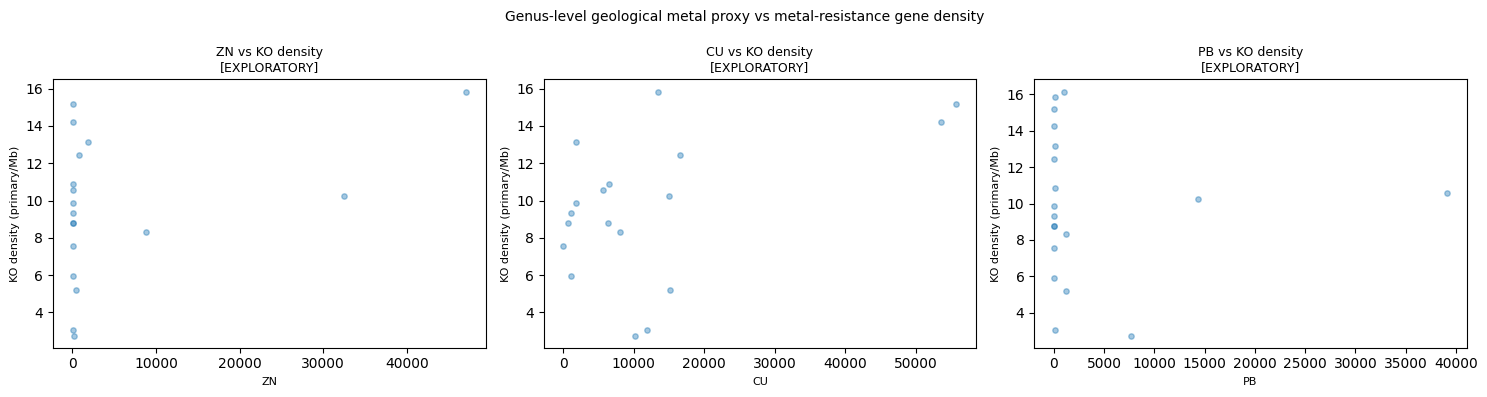

Saved: figures/07_metal_exposure_vs_ko_density.png


In [3]:
from scipy import stats as _stats

# Identify metal exposure columns in geo_niche (expect *_mean suffix, e.g. Cu_mean)
geo_metal_cols = [c for c in geo_niche.columns if c.endswith('_mean') and c != 'ph_mean']
print(f'Metal exposure columns in geo_niche: {geo_metal_cols}')

merged = bac_tax.merge(
    geo_niche[['genus_lower'] + geo_metal_cols
              + (['ph_mean'] if 'ph_mean' in geo_niche.columns else [])],
    on='genus_lower', how='inner',
)
print(f'Genera with KO + metal exposure data: {len(merged)}')

corr_rows = []
for mc in geo_metal_cols:
    metal = mc.replace('_mean', '').upper()
    pair_ko = merged[['ko_per_mb_primary', mc]].dropna()
    pair_ni = merged[['mean_levins_B_std', mc]].dropna()
    if len(pair_ko) < 10:
        continue
    r_ko, p_ko = _stats.spearmanr(pair_ko['ko_per_mb_primary'], pair_ko[mc])
    r_ni, p_ni = _stats.spearmanr(pair_ni['mean_levins_B_std'], pair_ni[mc])
    corr_rows.append({'metal': metal, 'col': mc, 'n': len(pair_ko),
                      'r_vs_ko_density':   round(r_ko, 3), 'p_vs_ko':    round(p_ko, 4),
                      'r_vs_niche_breadth': round(r_ni, 3), 'p_vs_niche': round(p_ni, 4)})

corr_df = pd.DataFrame(corr_rows) if corr_rows else pd.DataFrame()
if len(corr_df):
    print('\nSpearman correlations [EXPLORATORY — unadjusted]:')
    print(corr_df[['metal','n','r_vs_ko_density','p_vs_ko','r_vs_niche_breadth','p_vs_niche']].to_string(index=False))
else:
    print('\nNo correlations computed. Available geo_niche columns:')
    print(geo_niche.columns.tolist())

# Scatter plots for top 3 metals by |r| vs KO density
top_cols = (corr_df.reindex(corr_df['r_vs_ko_density'].abs().nlargest(3).index)['col'].tolist()
            if len(corr_df) >= 3 else geo_metal_cols[:3])
if top_cols:
    n_p = len(top_cols)
    fig, axes = plt.subplots(1, n_p, figsize=(5 * n_p, 4))
    if n_p == 1:
        axes = [axes]
    for ax, mc in zip(axes, top_cols):
        sub = merged[['ko_per_mb_primary', mc]].dropna()
        ax.scatter(sub[mc], sub['ko_per_mb_primary'], alpha=0.4, s=15, color='#1f77b4')
        ax.set_xlabel(mc.replace('_mean', '').upper(), fontsize=8)
        ax.set_ylabel('KO density (primary/Mb)', fontsize=8)
        ax.set_title(f'{mc.replace("_mean","").upper()} vs KO density\n[EXPLORATORY]', fontsize=9)
    plt.suptitle('Genus-level geological metal proxy vs metal-resistance gene density', fontsize=10)
    plt.tight_layout()
    fig.savefig(FIGS / '07_metal_exposure_vs_ko_density.png', dpi=150)
    plt.show()
    print('Saved: figures/07_metal_exposure_vs_ko_density.png')


In [4]:
cmmi_cov = None
if _SPARK_AVAILABLE:
    try:
        print('CMMI ores coverage check (Spark)...')
        cmmi_df = _spark.sql('SELECT * FROM arkinlab_envdbs.cmmi_ores LIMIT 50000').toPandas()
        cmmi_df.columns = [c.lower() for c in cmmi_df.columns]
        lat_col = next((c for c in cmmi_df.columns if c in ('lat', 'latitude', 'y')), None)
        lon_col = next((c for c in cmmi_df.columns if c in ('lon', 'longitude', 'x')), None)
        if lat_col and lon_col:
            cmmi_df['lat'] = pd.to_numeric(cmmi_df[lat_col], errors='coerce')
            cmmi_df['lon'] = pd.to_numeric(cmmi_df[lon_col], errors='coerce')
            cmmi_df = cmmi_df.dropna(subset=['lat', 'lon'])
            print(f'CMMI ores sites: {len(cmmi_df)}')
            analysis_pts = pd.read_csv(DATA / 'sample_latlon_env.csv')
            for col_name, alts in [('lat', ['LatitudeParsed', 'lat']), ('lon', ['LongitudeParsed', 'lon'])]:
                src = next((c for c in alts if c in analysis_pts.columns), None)
                if src:
                    analysis_pts['_lat'] = pd.to_numeric(analysis_pts['LatitudeParsed' if 'LatitudeParsed' in analysis_pts.columns else 'lat'], errors='coerce')
                    analysis_pts['_lon'] = pd.to_numeric(analysis_pts['LongitudeParsed' if 'LongitudeParsed' in analysis_pts.columns else 'lon'], errors='coerce')
            analysis_pts = analysis_pts.dropna(subset=['_lat', '_lon'])
            analysis_pts = analysis_pts.rename(columns={'_lat': 'lat', '_lon': 'lon'})
            sample_pts = analysis_pts[['lat', 'lon']].sample(n=min(5000, len(analysis_pts)), random_state=42)
            nearby = haversine_join(sample_pts, cmmi_df[['lat', 'lon']], max_dist_km=200)
            pct = round(100 * len(nearby) / len(sample_pts), 1)
            cmmi_cov = {'pct_matched': pct, 'n_analysis_pts': len(sample_pts), 'n_cmmi': len(cmmi_df)}
            print(f'CMMI coverage: {pct}% of analysis pts within 200 km of an ore deposit')
        else:
            print(f'CMMI lat/lon columns not found. Available: {cmmi_df.columns.tolist()[:10]}')
    except BaseException as _e:
        print(f'CMMI analysis FAILED: {str(_e)[:100]}')

if len(corr_df):
    corr_df.to_csv(DATA / '07_geological_proxies.csv', index=False)
    print('\nSaved: data/07_geological_proxies.csv')

print('\n=== NB07 REPORTING SUMMARY (EXPLORATORY) ===')
if len(corr_df):
    print(f'Local NGSA metal correlations: {len(corr_df)} metals analyzed')
    best = corr_df.nlargest(1, 'r_vs_ko_density').iloc[0]
    print(f'  Strongest r (vs KO density):    {best["metal"]} r={best["r_vs_ko_density"]:.3f} (p={best["p_vs_ko"]:.3f})')
    best_n = corr_df.nlargest(1, 'r_vs_niche_breadth').iloc[0]
    print(f'  Strongest r (vs niche breadth): {best_n["metal"]} r={best_n["r_vs_niche_breadth"]:.3f} (p={best_n["p_vs_niche"]:.3f})')
else:
    print('No local metal correlations (check geo_niche columns for *_mean)')
if cmmi_cov:
    print(f'CMMI ores: {cmmi_cov["pct_matched"]}% coverage, {cmmi_cov["n_cmmi"]} ore deposits')
print('\n[All findings EXPLORATORY — update INTERPRETATION_TABLE.md §7 if notable.]')


CMMI ores coverage check (Spark)...


CMMI ores sites: 29087


haversine_join: 2036/5000 query points matched within 200 km
CMMI coverage: 100.0% of analysis pts within 200 km of an ore deposit

Saved: data/07_geological_proxies.csv

=== NB07 REPORTING SUMMARY (EXPLORATORY) ===
Local NGSA metal correlations: 3 metals analyzed
  Strongest r (vs KO density):    ZN r=0.341 (p=0.167)
  Strongest r (vs niche breadth): CU r=0.263 (p=0.291)
CMMI ores: 100.0% coverage, 29087 ore deposits

[All findings EXPLORATORY — update INTERPRETATION_TABLE.md §7 if notable.]
